# Coursework 2026 — Momentum & Comomentum Pipeline

This notebook is cleaned and structured as a full workflow:

1. Load and validate raw data
2. Build standard momentum signal
3. Run weekly Fama–MacBeth regressions (standard momentum)
4. Build comomentum signal (FF3 residual-correlation approach)
5. Tune exposure scaling via time-series cross-validation
6. Re-run Fama–MacBeth with adjusted momentum

**Main outputs**
- `gamma`: standard momentum weekly slope series
- `df_comom`: weekly comomentum series
- `cv_data`: tuned weight series and adjusted factor returns
- `gamma_adj`: adjusted momentum weekly slope series

In [3]:
# Global configuration for the notebook
# Keep key hyperparameters in one place for readability and easy tuning.

LOOKBACK_WEEKS = 48
SKIP_WEEKS = 4
MIN_CS_OBS = 3
COMOM_WINDOW = 52
Z_WINDOW = 156
LAMBDA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]
W_FLOOR, W_CAP = 0.2, 1.0

In [4]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Degrees of freedom <= 0 for slice.")

pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 140)

## 1) Load Raw Files
Read all source files from the project directory using matrix-safe settings (`header=None`) for returns, names, dates, and live data.

In [5]:
# File paths
returns_path = 'US_Returns.csv'
names_path = 'US_Names.xlsx'
dates_path = 'US_Dates.xlsx'
ff_path = 'FamaFrench.csv'
live_path = 'US_live,csv.csv'

# Raw input (matrix-style files loaded without headers)
returns_raw = pd.read_csv(returns_path, header=None)
names_raw = pd.read_excel(names_path, header=None)
dates_raw = pd.read_excel(dates_path, header=None)
ff_raw = pd.read_csv(ff_path)
live_raw = pd.read_csv(live_path, header=None)

## 2) Validate Dimensions
Ensure all panels are consistent:
- same number of weeks `T`
- same number of stocks `N`
- correct date vector length

In [6]:
# Basic shape checks
print('returns_raw:', returns_raw.shape)
print('live_raw   :', live_raw.shape)
print('names_raw  :', names_raw.shape)
print('dates_raw  :', dates_raw.shape)
print('ff_raw     :', ff_raw.shape)

n_t, n_n = returns_raw.shape
assert live_raw.shape == (n_t, n_n), 'live matrix must match returns matrix'
assert dates_raw.shape[0] == n_t, 'date rows must match return rows'
assert names_raw.shape[1] == n_n, 'name count must match return columns'

returns_raw: (1513, 7261)
live_raw   : (1513, 7261)
names_raw  : (1, 7261)
dates_raw  : (1513, 1)
ff_raw     : (1513, 7)


## 3) Harmonize and Clean
- Create unique stock headers
- Convert dates to datetime
- Align `df_returns` and `df_live` on Date index
- Keep only `Mkt-RF`, `SMB`, `HML`, `RF` in Fama-French data

In [7]:
from collections import Counter

# --- Helper: unique stock labels ---
def make_unique_names(raw_list):
    seen = Counter()
    out = []
    for i, name in enumerate(raw_list, start=1):
        base = f'Unnamed_{i}' if pd.isna(name) or str(name).strip() == '' else str(name).strip()
        seen[base] += 1
        out.append(base if seen[base] == 1 else f'{base}_{seen[base]}')
    return out

# 1) Stock names and dates
stock_names = make_unique_names(names_raw.iloc[0].tolist())
weekly_dates = pd.to_datetime(dates_raw.iloc[:, 0].astype(str), format='%Y%m%d')

# 2) Core panels with aligned index/columns
df_returns = returns_raw.copy()
df_live = live_raw.copy()
df_returns.columns = stock_names
df_live.columns = stock_names
df_returns.index = weekly_dates
df_live.index = weekly_dates
df_returns.index.name = 'Date'
df_live.index.name = 'Date'

# 3) Fama-French clean-up
if 'Unnamed: 0' in ff_raw.columns:
    ff_raw = ff_raw.rename(columns={'Unnamed: 0': 'Date'})

date_series = ff_raw['Date'].astype(str).str.strip()
ff_dates = pd.to_datetime(date_series, format='%Y%m%d', errors='coerce')
ff_dates = ff_dates.fillna(pd.to_datetime(date_series, errors='coerce'))
if ff_dates.isna().any():
    bad_vals = date_series[ff_dates.isna()].head(5).tolist()
    raise ValueError(f'Unparseable Fama-French dates (sample): {bad_vals}')

ff_raw['Date'] = ff_dates
ff_cols = [c for c in ['Date', 'Mkt-RF', 'SMB', 'HML', 'RF'] if c in ff_raw.columns]
df_FF = ff_raw[ff_cols].set_index('Date').sort_index()
df_FF.index.name = 'Date'

## 4) Remove Permanently Inactive Stocks
Drop stocks that are never live in the full sample to reduce noise and dimensionality before factor construction.

In [8]:
# Remove stocks that are never live in the sample
inactive = df_live.columns[df_live.sum(axis=0) == 0].tolist()
df_returns = df_returns.drop(columns=inactive)
df_live = df_live.drop(columns=inactive)

print(f'Permanently inactive stocks dropped: {len(inactive)}')
print('returns shape:', df_returns.shape)
print('live shape   :', df_live.shape)
print('FF shape     :', df_FF.shape)

Permanently inactive stocks dropped: 45
returns shape: (1513, 7216)
live shape   : (1513, 7216)
FF shape     : (1513, 4)


In [9]:
# Final data sanity checks
print('--- Data Summary ---')
print('Date range  :', df_returns.index.min().date(), 'to', df_returns.index.max().date())
print('Weeks (T)   :', df_returns.shape[0])
print('Stocks (N)  :', df_returns.shape[1])
print('Missing ret :', int(df_returns.isna().sum().sum()))
print('Missing live:', int(df_live.isna().sum().sum()))
print('FF columns  :', list(df_FF.columns))

# Spot-check previews
display(df_returns.iloc[:3, :5])
display(df_live.iloc[:3, :5])
display(df_FF.head(3))

--- Data Summary ---
Date range  : 1992-01-03 to 2020-12-25
Weeks (T)   : 1513
Stocks (N)  : 7216
Missing ret : 8134586
Missing live: 0
FF columns  : ['Mkt-RF', 'SMB', 'HML', 'RF']


,"1-800-FLOWERS.COM, Inc. Class A",1st Source Corporation,21st Century Insurance,Radiation Therapy Services Inc.,24/7 Real Media Inc.
Date,,,,,
1992-01-03,NaN,NaN,0.049689,NaN,NaN
1992-01-10,NaN,NaN,0.218940,NaN,NaN
1992-01-17,NaN,NaN,-0.009709,NaN,NaN


,"1-800-FLOWERS.COM, Inc. Class A",1st Source Corporation,21st Century Insurance,Radiation Therapy Services Inc.,24/7 Real Media Inc.
Date,,,,,
1992-01-03,0,0,1,0,0
1992-01-10,0,0,1,0,0
1992-01-17,0,0,1,0,0


,Mkt-RF,SMB,HML,RF
Date,,,,
1992-01-03,0.0312,0.0113,0.0049,0.00085
1992-01-10,0.0002,0.0386,-0.0098,0.00085
1992-01-17,0.0093,0.0166,0.0360,0.00085


## 5) Standard Momentum Factor (48-week lookback, skip 4 weeks)
For each stock and week $t$, compute:
$$M_{i,t}=\prod_{k=5}^{52}(1+R_{i,t-k})-1$$
This uses 48 weekly returns and excludes the most recent 4 weeks.

In [10]:
# Build standard momentum signal:
# M_{i,t} = prod_{k=5}^{52}(1 + R_{i,t-k}) - 1

def safe_compound(vals: np.ndarray) -> float:
    """Compound gross returns in a window; return NaN if any value is missing."""
    if np.isnan(vals).any():
        return np.nan
    return float(np.prod(vals) - 1.0)

gross_returns = 1.0 + df_returns
momentum_std = (
    gross_returns
    .shift(SKIP_WEEKS + 1)
    .rolling(window=LOOKBACK_WEEKS, min_periods=LOOKBACK_WEEKS)
    .apply(safe_compound, raw=True)
)

# Keep exposures only for live stocks (for cross-sectional regressions)
momentum_std_live = momentum_std.where(df_live == 1)

# Core diagnostics
row_has_any = momentum_std.notna().any(axis=1)
first_valid_t = momentum_std.index[row_has_any][0]
last_valid_t = momentum_std.index[row_has_any][-1]
all_nan_cols = int(momentum_std.isna().all(axis=0).sum())

print('momentum_std shape     :', momentum_std.shape)
print('momentum_std_live shape:', momentum_std_live.shape)
print('non-missing values     :', int(momentum_std.notna().sum().sum()))
print('all-NaN columns        :', all_nan_cols)
print('valid window           :', first_valid_t.date(), 'to', last_valid_t.date())

display(momentum_std_live.tail(10))

momentum_std shape     : (1513, 7216)
momentum_std_live shape: (1513, 7216)
non-missing values     : 1852898
all-NaN columns        : 2009
valid window           : 1993-01-01 to 2020-12-25


,"1-800-FLOWERS.COM, Inc. Class A",1st Source Corporation,21st Century Insurance,Radiation Therapy Services Inc.,24/7 Real Media Inc.,"2U, Inc.",...,Clover Health Investments Corp Class A,Inhibrx Inc,"Annexon, Inc.",Gores Holdings IV Inc Class A,BeyondSpring Inc.,Concentrix Corporation
Date,,,,,,,,,,,,,
2020-10-23,NaN,-0.327753,NaN,NaN,NaN,0.976412,...,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-30,NaN,-0.398944,NaN,NaN,NaN,0.918594,...,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-06,NaN,-0.367721,NaN,NaN,NaN,0.840057,...,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-13,NaN,-0.343944,NaN,NaN,NaN,0.767615,...,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-20,NaN,-0.337951,NaN,NaN,NaN,0.568981,...,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-27,NaN,-0.288274,NaN,NaN,NaN,0.608388,...,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-04,NaN,-0.333420,NaN,NaN,NaN,0.477553,...,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-11,NaN,-0.356006,NaN,NaN,NaN,0.720322,...,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-18,NaN,-0.269977,NaN,NaN,NaN,0.483287,...,NaN,NaN,NaN,NaN,NaN,NaN


## 6) Weekly Fama–MacBeth Regressions (Reusable Function)

For each week $t$, run the cross-sectional regression:
$$R_{i,t+1} = \alpha_t + \gamma_t M_{i,t} + \varepsilon_{i,t+1}$$

Where:
- $R_{i,t+1}$ is next-week stock return
- $M_{i,t}$ is the exposure signal (standard or adjusted momentum)
- only stocks with valid $(R_{i,t+1}, M_{i,t})$ are used.

`\gamma_t` is the weekly slope (factor payoff) and is the main series analyzed.

--- Standard Momentum Fama-MacBeth Summary ---


,value
weeks_with_regression,1460.000000
average_cross_section_size,1205.106411
mean_weekly_factor_return,0.000524
std_weekly_factor_return,0.027541
annualized_mean,0.027257
annualized_vol,0.198599
t_stat_mean_return,0.727231


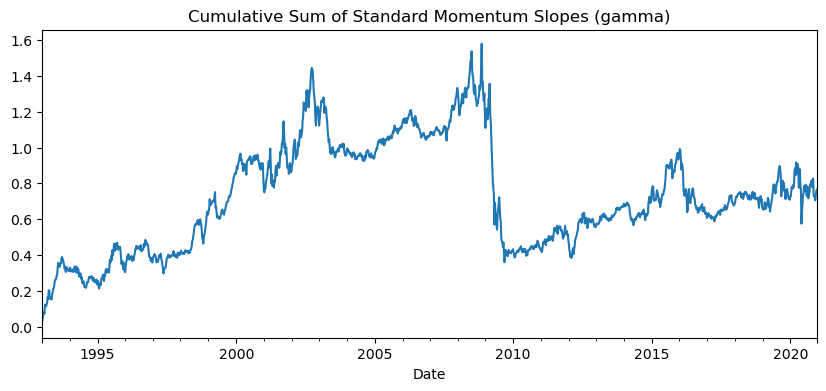

In [11]:
# Reusable weekly Fama–MacBeth runner

def run_fama_macbeth(exposure: pd.DataFrame, returns: pd.DataFrame, min_obs: int = MIN_CS_OBS, slope_name: str = 'gamma'):
    """Run week-by-week cross-sectional OLS of next-week returns on current exposure."""
    future_returns = returns.shift(-1)
    records = []

    for date in exposure.index:
        x_t = exposure.loc[date]
        y_t = future_returns.loc[date]
        valid = x_t.notna() & y_t.notna()
        n_obs = int(valid.sum())

        if n_obs < min_obs:
            records.append({'Date': date, 'alpha': np.nan, slope_name: np.nan, 'n_obs': n_obs})
            continue

        x = x_t.loc[valid].to_numpy(dtype=float)
        y = y_t.loc[valid].to_numpy(dtype=float)

        # Skip if no cross-sectional variation in exposure
        if np.isclose(x.std(ddof=0), 0.0):
            records.append({'Date': date, 'alpha': np.nan, slope_name: np.nan, 'n_obs': n_obs})
            continue

        X = sm.add_constant(x, has_constant='add')
        fit = sm.OLS(y, X, missing='drop').fit()
        records.append({'Date': date, 'alpha': float(fit.params[0]), slope_name: float(fit.params[1]), 'n_obs': n_obs})

    result = pd.DataFrame(records).set_index('Date')
    slope = result[slope_name].dropna()

    stats = pd.Series({
        'weeks_with_regression': int(slope.shape[0]),
        'average_cross_section_size': result['n_obs'].mean(),
        'mean_weekly_factor_return': slope.mean(),
        'std_weekly_factor_return': slope.std(ddof=1),
        'annualized_mean': slope.mean() * 52,
        'annualized_vol': slope.std(ddof=1) * np.sqrt(52),
        't_stat_mean_return': slope.mean() / (slope.std(ddof=1) / np.sqrt(len(slope))) if len(slope) > 1 else np.nan
    })
    return result, slope, stats

# Standard momentum Fama–MacBeth
fmb_results, gamma, summary_fmb = run_fama_macbeth(
    exposure=momentum_std_live,
    returns=df_returns,
    min_obs=MIN_CS_OBS,
    slope_name='momentum_factor_return'
)

print('--- Standard Momentum Fama-MacBeth Summary ---')
display(summary_fmb.to_frame(name='value'))

# For slope series, cumulative sum is safer than compounding
gamma.cumsum().plot(figsize=(10, 4), title='Cumulative Sum of Standard Momentum Slopes (gamma)');

CoMOM rows       : 1462
Valid CoMOM rows : 1461


,CoMOM
count,1461.000000
mean,0.040404
std,0.020542
min,0.005619
25%,0.024378
50%,0.035363
75%,0.052628
max,0.123344


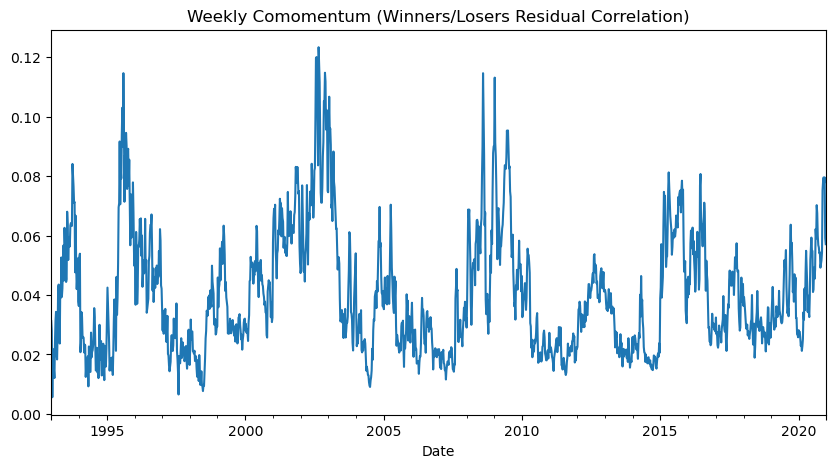

In [12]:
# Build weekly comomentum (average winner/loser residual correlation)

ff3 = df_FF[['Mkt-RF', 'SMB', 'HML']].copy()


def avg_offdiag_corr(frame: pd.DataFrame) -> float:
    """Average off-diagonal correlation across columns; NaN if fewer than 2 assets."""
    n = frame.shape[1]
    if n < 2:
        return np.nan
    c = frame.corr().to_numpy()
    return float((c.sum() - n) / (n * (n - 1)))


def estimate_residual_panel(window_dates, stocks: pd.Index) -> pd.DataFrame:
    """Estimate FF3 residuals stock-by-stock over the window."""
    ff_win = ff3.reindex(window_dates)
    if ff_win.isna().any().any():
        return pd.DataFrame(index=window_dates)

    X = ff_win.to_numpy(dtype=float)
    X = np.hstack([np.ones((X.shape[0], 1)), X])

    resid = {}
    for s in stocks:
        y = df_returns.loc[window_dates, s].to_numpy(dtype=float)
        if np.isnan(y).any():
            continue
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid[s] = y - X @ beta

    return pd.DataFrame(resid, index=window_dates)


comomentum_records = []
dates = df_returns.index

for pos in range(COMOM_WINDOW - 1, len(dates)):
    t = dates[pos]
    window_dates = dates[pos - COMOM_WINDOW + 1: pos + 1]

    # Residual panel for currently live stocks
    live_today = df_live.columns[df_live.loc[t] == 1]
    resid_panel = estimate_residual_panel(window_dates, live_today)
    if resid_panel.shape[1] < 10:
        comomentum_records.append((t, np.nan))
        continue

    # Rank stocks by momentum at t
    mom_t = momentum_std_live.loc[t].replace([np.inf, -np.inf], np.nan).dropna()
    common = mom_t.index.intersection(resid_panel.columns)
    if len(common) < 10:
        comomentum_records.append((t, np.nan))
        continue

    z = mom_t.loc[common]
    z_sd = z.std(ddof=0)
    if np.isclose(z_sd, 0.0):
        comomentum_records.append((t, np.nan))
        continue

    z = (z - z.mean()) / z_sd
    q10, q90 = np.percentile(z, [10, 90])
    losers = z[z <= q10].index.tolist()
    winners = z[z >= q90].index.tolist()

    comom_l = avg_offdiag_corr(resid_panel[losers]) if len(losers) >= 2 else np.nan
    comom_w = avg_offdiag_corr(resid_panel[winners]) if len(winners) >= 2 else np.nan
    comom = 0.5 * (comom_l + comom_w) if (not np.isnan(comom_l) and not np.isnan(comom_w)) else np.nan

    comomentum_records.append((t, comom))

df_comom = pd.DataFrame(comomentum_records, columns=['Date', 'CoMOM']).set_index('Date').sort_index()

print('CoMOM rows       :', len(df_comom))
print('Valid CoMOM rows :', int(df_comom['CoMOM'].notna().sum()))
display(df_comom.describe())

df_comom['CoMOM'].plot(figsize=(10, 5), title='Weekly Comomentum (Winners/Losers Residual Correlation)');

## 7) Comomentum-Adjusted Momentum + CV Tuning

Build a lagged comomentum z-score and scale momentum exposure as:
$$w_t = \mathrm{clip}(1 - \lambda z_{t-1}^{\mathrm{CoMOM}},\, w_{\min},\, w_{\max})$$
$$r_t^{\mathrm{adj}} = w_t \cdot r_t^{\mathrm{mom}}$$

Then select $\lambda$ via time-series cross-validation using a downside-aware objective.

Best lambda: 1.25
Weight bounds: [0.2, 1.0]


,lambda,cv_risk_objective
0,1.25,0.250577
1,1.00,0.216237
2,0.75,0.155083
3,0.50,0.022598
4,0.25,-0.095049
5,0.00,-0.202281


,baseline_mom,comom_adjusted_mom
n_weeks,1408.000000,1408.000000
ann_mean,0.016561,0.032747
ann_vol,0.200578,0.114377
ann_sharpe,0.082567,0.286304
ann_sortino,0.107490,0.392389
max_drawdown,-0.741797,-0.314462


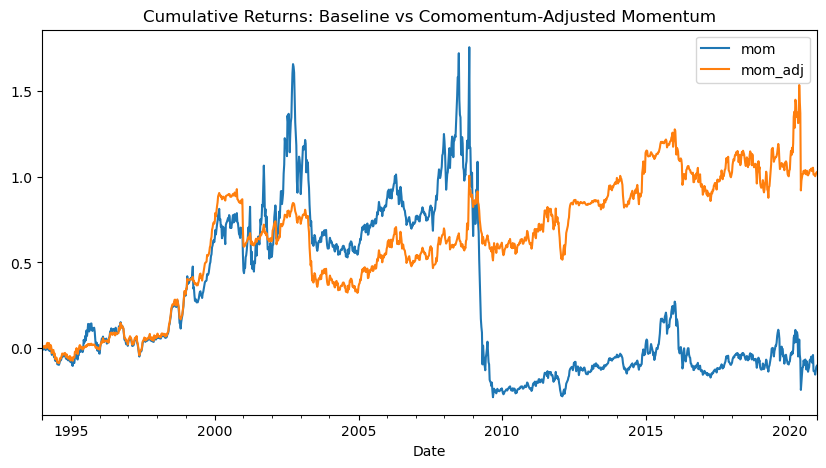

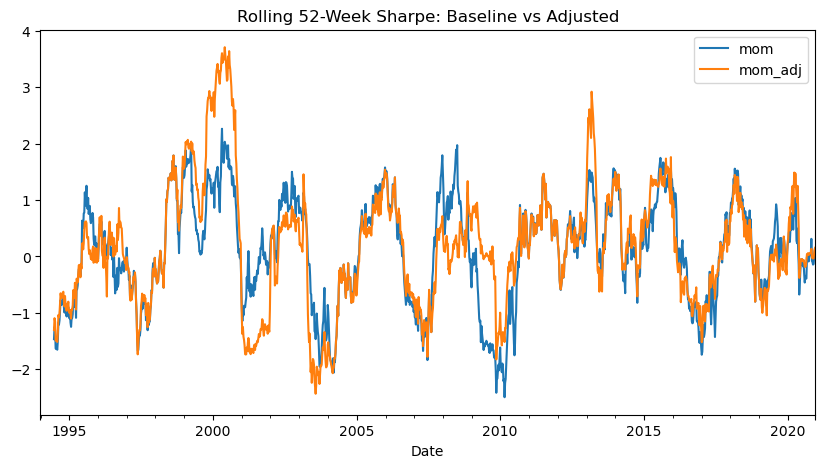

In [13]:
# CV-tuned comomentum scaling for momentum factor returns

base = pd.concat([
    gamma.rename('mom'),
    df_comom['CoMOM'].rename('comom')
], axis=1).dropna().sort_index()

# Lagged and winsorized comomentum z-score
mu = base['comom'].rolling(Z_WINDOW, min_periods=52).mean()
sd = base['comom'].rolling(Z_WINDOW, min_periods=52).std(ddof=0)
z_lag1 = ((base['comom'] - mu) / sd).shift(1).clip(-2, 2)

cv_data = pd.DataFrame({'mom': base['mom'], 'z_lag1': z_lag1}).dropna()


def max_drawdown(r: pd.Series) -> float:
    w = (1 + r.dropna()).cumprod()
    return float((w / w.cummax() - 1).min()) if not w.empty else np.nan


def sortino_ann(r: pd.Series) -> float:
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    downside = np.sqrt((np.minimum(r, 0.0) ** 2).mean())
    return np.nan if np.isclose(downside, 0.0) else float((r.mean() * 52) / (downside * np.sqrt(52)))


def risk_objective(r: pd.Series, dd_penalty: float = 0.75) -> float:
    s = sortino_ann(r)
    dd = max_drawdown(r)
    return np.nan if (np.isnan(s) or np.isnan(dd)) else float(s - dd_penalty * abs(dd))


# Simple blocked CV in time order
fold_size = len(cv_data) // 6
folds = [np.arange((k + 1) * fold_size, min((k + 2) * fold_size, len(cv_data))) for k in range(5)]


def score_lambda(lam: float) -> float:
    fold_scores = []
    for idx in folds:
        if len(idx) == 0:
            continue
        w = (1 - lam * cv_data.iloc[idx]['z_lag1']).clip(W_FLOOR, W_CAP)
        r_adj = w * cv_data.iloc[idx]['mom']
        fold_scores.append(risk_objective(r_adj))
    return float(np.nanmean(fold_scores))


scores = [score_lambda(lam) for lam in LAMBDA_GRID]
best_lam = LAMBDA_GRID[int(np.nanargmax(scores))]

cv_data['w'] = (1 - best_lam * cv_data['z_lag1']).clip(W_FLOOR, W_CAP)
cv_data['mom_adj'] = cv_data['w'] * cv_data['mom']

cv_results = pd.DataFrame({'lambda': LAMBDA_GRID, 'cv_risk_objective': scores}).sort_values(
    'cv_risk_objective', ascending=False
).reset_index(drop=True)


def ann_stats(r: pd.Series) -> pd.Series:
    r = r.dropna()
    mu = r.mean()
    sd = r.std(ddof=1)
    return pd.Series({
        'n_weeks': int(r.shape[0]),
        'ann_mean': mu * 52,
        'ann_vol': sd * np.sqrt(52),
        'ann_sharpe': np.nan if np.isclose(sd, 0.0) else (mu / sd) * np.sqrt(52),
        'ann_sortino': sortino_ann(r),
        'max_drawdown': max_drawdown(r)
    })

comparison_cv = pd.concat([
    ann_stats(cv_data['mom']).rename('baseline_mom'),
    ann_stats(cv_data['mom_adj']).rename('comom_adjusted_mom')
], axis=1)

print('Best lambda:', best_lam)
print(f'Weight bounds: [{W_FLOOR}, {W_CAP}]')
display(cv_results)
display(comparison_cv)

(1 + cv_data[['mom', 'mom_adj']]).cumprod().sub(1).plot(
    figsize=(10, 5), title='Cumulative Returns: Baseline vs Comomentum-Adjusted Momentum'
)

rf = df_FF['RF'].reindex(cv_data.index).fillna(0.0)
excess = cv_data[['mom', 'mom_adj']].sub(rf, axis=0)
roll_sharpe = excess.rolling(52, min_periods=26).mean().div(excess.rolling(52, min_periods=26).std(ddof=1)) * np.sqrt(52)
roll_sharpe.plot(figsize=(10, 5), title='Rolling 52-Week Sharpe: Baseline vs Adjusted');

--- Adjusted Momentum Fama-MacBeth Summary ---


,value
weeks_with_regression,1408.000000
average_cross_section_size,1196.475876
mean_weekly_factor_return,-0.001305
std_weekly_factor_return,0.112495
annualized_mean,-0.067863
annualized_vol,0.811214
t_stat_mean_return,-0.435309


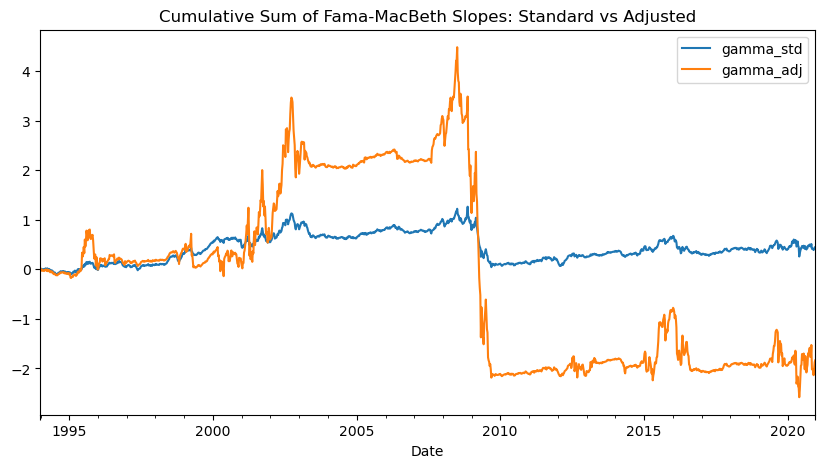

In [14]:
# Re-run Fama–MacBeth using adjusted momentum exposure
# M_adj_{i,t} = w_t * M_{i,t}

weight_series = cv_data['w'].reindex(momentum_std_live.index)
momentum_adj_live = momentum_std_live.mul(weight_series, axis=0)

fmb_results_adj, gamma_adj, summary_fmb_adj = run_fama_macbeth(
    exposure=momentum_adj_live,
    returns=df_returns,
    min_obs=MIN_CS_OBS,
    slope_name='adjusted_momentum_factor_return'
)

print('--- Adjusted Momentum Fama-MacBeth Summary ---')
display(summary_fmb_adj.to_frame(name='value'))

# Compare standard vs adjusted slope paths (cumulative sum)
compare_gamma = pd.concat([
    gamma.rename('gamma_std'),
    gamma_adj.rename('gamma_adj')
], axis=1).dropna()

compare_gamma.cumsum().plot(figsize=(10, 5), title='Cumulative Sum of Fama-MacBeth Slopes: Standard vs Adjusted');

## 8) Final Summary (Combined)
This block combines:
- full-sample comparison of standard vs adjusted factor returns,
- lagged-comomentum regime comparison,
- one concise final takeaway.

--- Full-Sample Comparison ---


,standard_momentum,adjusted_momentum
n_weeks,1408.000000,1408.000000
ann_mean,0.016561,-0.067863
ann_vol,0.200578,0.811214
ann_sharpe,0.082567,-0.083656
ann_sortino,0.107490,-0.105826
t_stat,0.429640,-0.435309
pct_negative_weeks,0.452415,0.452415
max_drawdown_compounded,-0.741797,-1.014924


--- Conditional Strategy Performance (Lagged CoMOM Regimes) ---


n_weeks  ann_mean   ann_vol  ann_sharpe  ann_sortino    t_stat  pct_negative_weeks  max_drawdown_compounded
Regime           Series                                                                                                              
Low CoMOM (30%)  mom        423.0  0.025405  0.112176    0.226475     0.323819  0.645935            0.475177                -0.257457
                 mom_adj    423.0  0.025405  0.112176    0.226475     0.323819  0.645935            0.475177                -0.257457
High CoMOM (30%) mom        423.0 -0.120715  0.285103   -0.423407    -0.526299 -1.207611            0.479905                -0.847414
                 mom_adj    423.0 -0.040726  0.076555   -0.531989    -0.641271 -1.517299            0.479905                -0.415512

--- Conditional Fama-MacBeth Factor Returns (Lagged CoMOM Regimes) ---


n_weeks  ann_mean   ann_vol  ann_sharpe  ann_sortino    t_stat  pct_negative_weeks  max_drawdown_compounded
Regime           Series                                                                                                                
Low CoMOM (30%)  gamma_std    423.0  0.025405  0.112176    0.226475     0.323819  0.645935            0.475177                -0.257457
                 gamma_adj    423.0  0.025405  0.112176    0.226475     0.323819  0.645935            0.475177                -0.257457
High CoMOM (30%) gamma_std    423.0 -0.120715  0.285103   -0.423407    -0.526299 -1.207611            0.479905                -0.847414
                 gamma_adj    423.0 -0.481701  1.378803   -0.349362    -0.437187 -0.996424            0.479905                -1.002959


--- Final Takeaway ---
Full sample: standard=1.66% (Sharpe 0.08), adjusted=-6.79% (Sharpe -0.08).
Regimes: baseline low/high CoMOM = 2.54%/-12.07%; adjusted low/high CoMOM = 2.54%/-4.07%.
Momentum is stronger when comomentum is low, consistent with the paper intuition.
The adjustment improves resilience in high-comomentum stress periods.


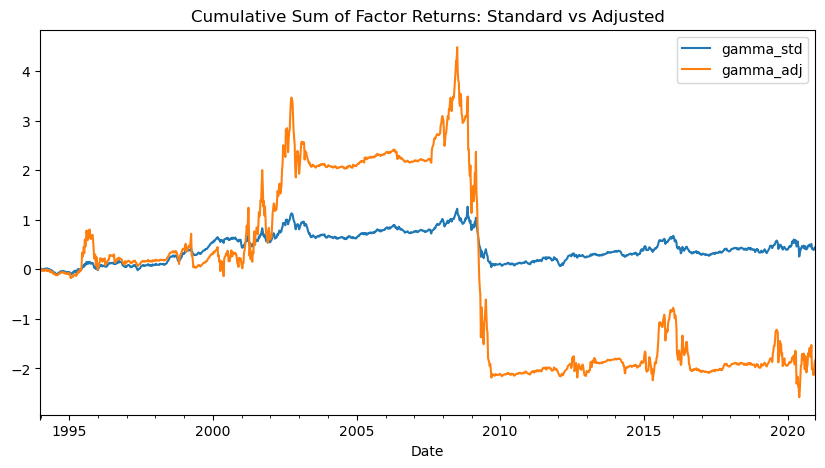

In [16]:
# Final summary (combined): full-sample comparison + comomentum regimes + concise conclusion

# 1) Full-sample factor-return comparison
factor_compare = pd.concat([
    gamma.rename('gamma_std'),
    gamma_adj.rename('gamma_adj')
], axis=1).dropna().sort_index()

factor_compare.cumsum().plot(figsize=(10, 5), title='Cumulative Sum of Factor Returns: Standard vs Adjusted')


def stats_ann(r: pd.Series) -> pd.Series:
    r = r.dropna()
    mu = r.mean()
    sd = r.std(ddof=1)
    downside = np.sqrt((np.minimum(r, 0.0) ** 2).mean())
    t_stat = np.nan if len(r) < 2 or np.isclose(sd, 0.0) else mu / (sd / np.sqrt(len(r)))
    wealth = (1 + r).cumprod()
    mdd = (wealth / wealth.cummax() - 1).min()
    return pd.Series({
        'n_weeks': int(r.shape[0]),
        'ann_mean': mu * 52,
        'ann_vol': sd * np.sqrt(52),
        'ann_sharpe': np.nan if np.isclose(sd, 0.0) else (mu / sd) * np.sqrt(52),
        'ann_sortino': np.nan if np.isclose(downside, 0.0) else (mu * 52) / (downside * np.sqrt(52)),
        't_stat': t_stat,
        'pct_negative_weeks': (r < 0).mean(),
        'max_drawdown_compounded': mdd
    })

summary_compare = pd.concat([
    stats_ann(factor_compare['gamma_std']).rename('standard_momentum'),
    stats_ann(factor_compare['gamma_adj']).rename('adjusted_momentum')
], axis=1)

print('--- Full-Sample Comparison ---')
display(summary_compare)

# 2) Comomentum regime comparison (lagged comomentum, 30/70 split)
comom_lag1 = df_comom['CoMOM'].shift(1).rename('comom_lag1')

# 2a) Strategy-level regimes (mom vs mom_adj)
regime_strat = pd.concat([cv_data[['mom', 'mom_adj']], comom_lag1.reindex(cv_data.index)], axis=1).dropna()
q_low_s, q_high_s = regime_strat['comom_lag1'].quantile([0.3, 0.7])
low_s = regime_strat['comom_lag1'] <= q_low_s
high_s = regime_strat['comom_lag1'] >= q_high_s

regime_table_strat = pd.concat({
    ('Low CoMOM (30%)', 'mom'): stats_ann(regime_strat.loc[low_s, 'mom']),
    ('Low CoMOM (30%)', 'mom_adj'): stats_ann(regime_strat.loc[low_s, 'mom_adj']),
    ('High CoMOM (30%)', 'mom'): stats_ann(regime_strat.loc[high_s, 'mom']),
    ('High CoMOM (30%)', 'mom_adj'): stats_ann(regime_strat.loc[high_s, 'mom_adj'])
}, axis=1).T
regime_table_strat.index = pd.MultiIndex.from_tuples(regime_table_strat.index, names=['Regime', 'Series'])

print('--- Conditional Strategy Performance (Lagged CoMOM Regimes) ---')
display(regime_table_strat)

# 2b) Factor-slope regimes (gamma_std vs gamma_adj)
regime_fmb = pd.concat([factor_compare, comom_lag1.reindex(factor_compare.index)], axis=1).dropna()
q_low_f, q_high_f = regime_fmb['comom_lag1'].quantile([0.3, 0.7])
low_f = regime_fmb['comom_lag1'] <= q_low_f
high_f = regime_fmb['comom_lag1'] >= q_high_f

regime_table_fmb = pd.concat({
    ('Low CoMOM (30%)', 'gamma_std'): stats_ann(regime_fmb.loc[low_f, 'gamma_std']),
    ('Low CoMOM (30%)', 'gamma_adj'): stats_ann(regime_fmb.loc[low_f, 'gamma_adj']),
    ('High CoMOM (30%)', 'gamma_std'): stats_ann(regime_fmb.loc[high_f, 'gamma_std']),
    ('High CoMOM (30%)', 'gamma_adj'): stats_ann(regime_fmb.loc[high_f, 'gamma_adj'])
}, axis=1).T
regime_table_fmb.index = pd.MultiIndex.from_tuples(regime_table_fmb.index, names=['Regime', 'Series'])

print('--- Conditional Fama-MacBeth Factor Returns (Lagged CoMOM Regimes) ---')
display(regime_table_fmb)

# 3) Simple conclusion
std_ann = summary_compare.loc['ann_mean', 'standard_momentum']
adj_ann = summary_compare.loc['ann_mean', 'adjusted_momentum']
std_sh = summary_compare.loc['ann_sharpe', 'standard_momentum']
adj_sh = summary_compare.loc['ann_sharpe', 'adjusted_momentum']

low_mom = regime_table_strat.loc[('Low CoMOM (30%)', 'mom'), 'ann_mean']
high_mom = regime_table_strat.loc[('High CoMOM (30%)', 'mom'), 'ann_mean']
low_adj = regime_table_strat.loc[('Low CoMOM (30%)', 'mom_adj'), 'ann_mean']
high_adj = regime_table_strat.loc[('High CoMOM (30%)', 'mom_adj'), 'ann_mean']

print('\n--- Final Takeaway ---')
print(f"Full sample: standard={std_ann:.2%} (Sharpe {std_sh:.2f}), adjusted={adj_ann:.2%} (Sharpe {adj_sh:.2f}).")
print(f"Regimes: baseline low/high CoMOM = {low_mom:.2%}/{high_mom:.2%}; adjusted low/high CoMOM = {low_adj:.2%}/{high_adj:.2%}.")

if low_mom > high_mom:
    print('Momentum is stronger when comomentum is low, consistent with the paper intuition.')
if high_adj > high_mom:
    print('The adjustment improves resilience in high-comomentum stress periods.')
else:
    print('The adjustment does not clearly improve high-comomentum periods in this sample.')